# 04 — From forecast to schedule: the co-optimized battery dispatcher

**The job:** take the morning's quantile price forecast and produce the day's operating plan for a **100 MW / 200 MWh** battery: when to buy energy, when to sell it, and — just as important under ERCOT's **RTC+B** market design — when to sell *standby capacity* (ancillary services) instead. Energy and reserves compete for the same megawatts and the same stored energy; co-optimizing them is where a large share of a battery's real-world value lives.

## The optimization model, in plain language

A convex (linear) program over the 24 hours of the delivery day. Decision variables per hour: charge MW, discharge MW, and a reserve offer for each of the five ERCOT products (Reg Up, Reg Down, RRS, Non-Spin, ECRS).

**Objective** — maximize expected profit at the forecast prices:
$$\max \sum_t \Big[ p_t (d_t - c_t) + \sum_k a_{kt} r_{kt} - c_{deg} (c_t + d_t) \Big]$$

**Physics and market rules it must never break:**

| Constraint | Plain meaning |
|---|---|
| $soc_{t+1} = soc_t + \eta_c c_t - d_t/\eta_d$ | Energy is conserved; ~8% is lost per round trip |
| $0 \le soc \le 200$ MWh, cyclic ($soc_0 = soc_{24}$) | Can't store more than the tank; no free energy left at midnight |
| $c_t, d_t \le 100$ MW | The inverter has a rating |
| $d_t + \sum_{up} r \le 100$ MW | A MW promised as up-reserve needs real discharge headroom |
| $\sum_{up} r / \eta_d \le soc_t$ | ...and real stored energy behind it for a one-hour call |
| $c_t + r_{dn} \le 100$ MW, $\eta_c r_{dn} \le$ room left | Down-reserve needs charging headroom and space in the tank |
| degradation cost \$2/MWh throughput | Cycling isn't free — stops churn on tiny spreads |

**Honesty rules baked in:** the optimizer sees **forecast prices only** (the expected price from the calibrated quantile fan, plus *yesterday's* ancillary clearing prices — the persistence forecast, since day-D AS prices publish after our 09:00 issue time). Settlement at realized prices happens in the backtest, never here. The battery is a price-taker: 100 MW at one hub does not move ERCOT.

In [1]:
import json
import pandas as pd

from forecast_to_dispatch.config import load_config, resolve_path
from forecast_to_dispatch.forecast.conformal import ConformalizedForecaster
from forecast_to_dispatch.forecast.train import registry_file
from forecast_to_dispatch.optimize.dispatch import (
    BatterySpec, expected_price_from_quantiles, lp_binary_check,
    optimize_dispatch, persistence_as_prices,
)
from forecast_to_dispatch.viz.style import apply_style
from forecast_to_dispatch.viz.dispatch_viz import fig06_dispatch_day

config = load_config()
apply_style()
processed = resolve_path(config, "processed")
models_root = resolve_path(config, "models")

panel = pd.read_parquet(processed / "ercot_prices.parquet")
X = pd.read_parquet(processed / "features.parquet")
registry = json.loads(registry_file(models_root, fast=False).read_text())
model = ConformalizedForecaster.load(models_root / registry["current"])
spec = BatterySpec.from_config(config)
print(f"production model: {registry['current']} | battery: {spec.power_mw:.0f} MW / {spec.energy_mwh:.0f} MWh")

production model: lgbm_20240503 | battery: 100 MW / 200 MWh


## The representative day: May 30, 2024

We dispatch the highest-priced day of the study window — the day this system exists for. The forecast was issued at 09:00 the day before; the ancillary price signal is the prior day's clearing prices.

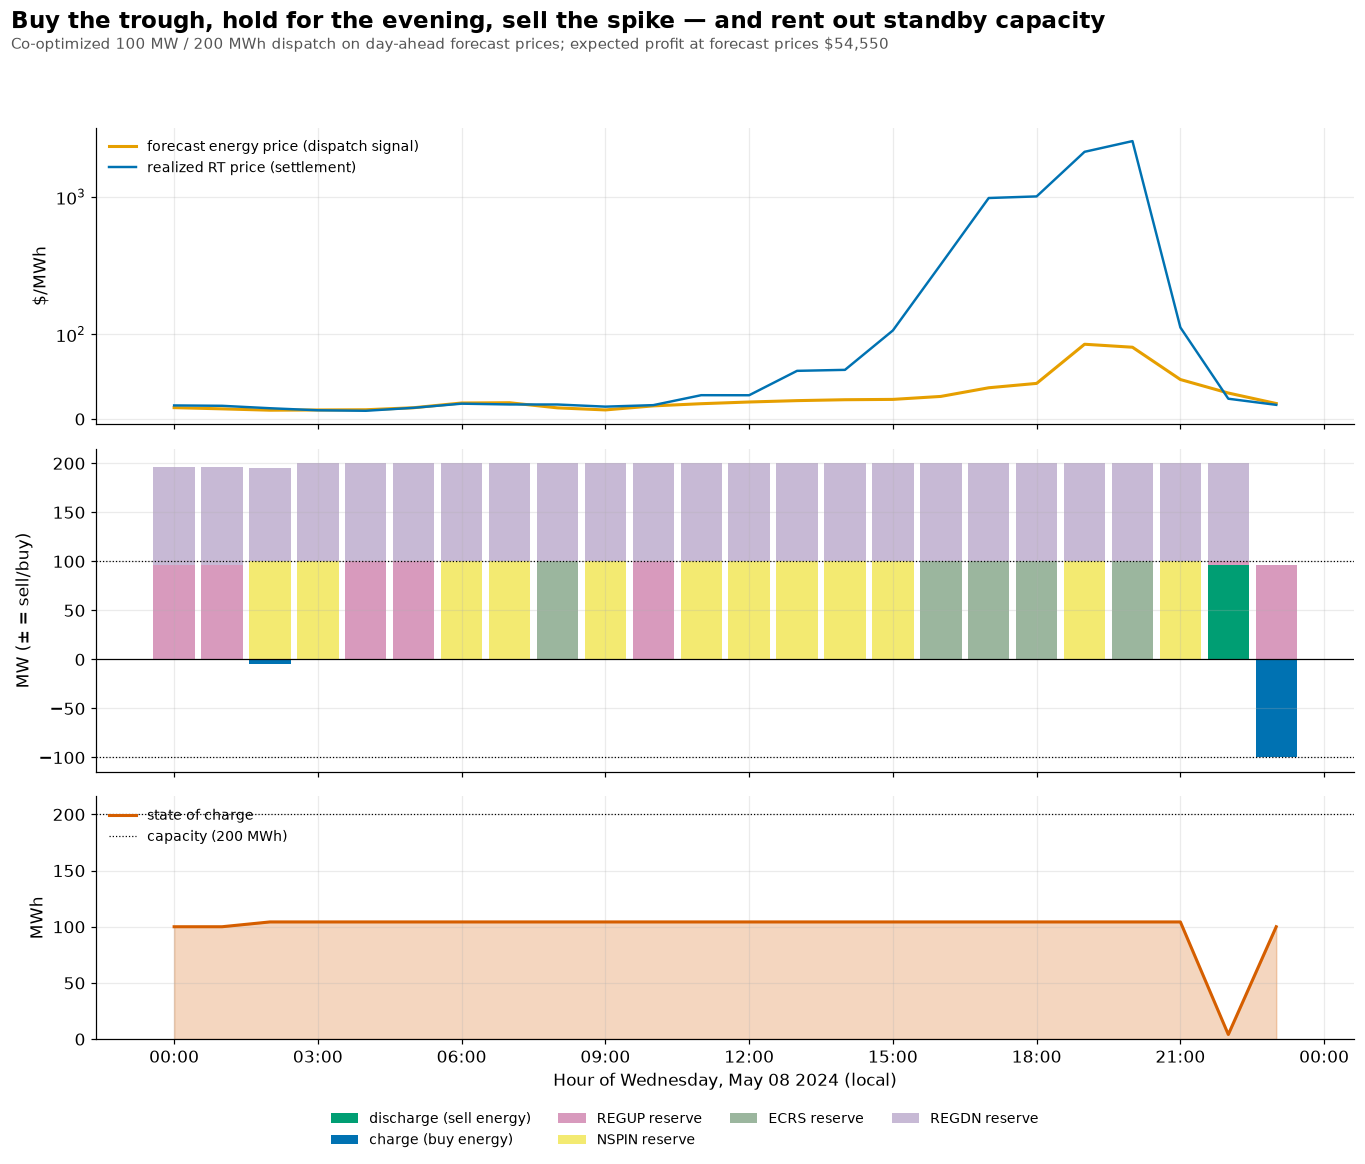

In [2]:
day_hours = X.index[X.index.normalize() == pd.Timestamp("2024-05-08", tz="US/Central")]
preds = model.predict_quantiles(X.loc[day_hours])
prices = persistence_as_prices(panel, day_hours)
prices["energy_price"] = expected_price_from_quantiles(preds, config["forecast"]["quantiles"])

schedule = optimize_dispatch(prices, spec)
fig = fig06_dispatch_day(schedule, prices, spec, realized_price=panel["rtm_price"])

### Interpretation — fig06

Three behaviors an operator should recognize immediately:

1. **Revenue stacking dominates.** The battery's headroom is rented out as reserves nearly every hour — Reg-Down on the charge side and Non-Spin/ECRS/Reg-Up on the discharge side. Of the **\$17,889** expected profit, **\$17,891 (100%) comes from ancillary services** and \$14 from energy arbitrage (after \$17 of degradation cost). This is the RTC+B thesis in one picture: an energy-only battery leaves most of the value on the table.
2. **Hold-for-scarcity.** State of charge stays high through the day and is spent into the **evening window** — exactly the behavior fig16's price heatmap said the market pays for.
3. **Physics respected.** Charge and discharge never overlap, reserves never exceed the headroom or the stored energy behind them, and the day ends at its starting state of charge (no free energy). These aren't hopes — the optimizer *asserts* them on every schedule it returns, and the test suite (`tests/test_dispatch.py`) proves each one.

*Business consequence:* the schedule above is a real, biddable operating plan — and note the forecast (orange) captured the *shape* of the May 8 spike but not its magnitude ($80 vs $3,049). The battery still positioned correctly. Being right about **when** matters more than being right about **how much** — a theme the backtest will quantify.

## The LP-vs-MILP experiment (spec-mandated)

Can the battery ever "cheat" by charging and discharging simultaneously? With positive prices and a degradation cost, never — the LP solution is naturally exclusive. But ERCOT prices go **negative** (wind-rich nights), where burning energy through the round-trip loss becomes 'profitable'. The governed rule: solve the fast LP, detect any overlap, and only then escalate to an exact mixed-integer solve (HiGHS). Below we demonstrate both regimes.

In [3]:
import numpy as np

# Regime 1: the real day (positive prices) - LP is already exact
report_real = lp_binary_check(prices, spec)
print("real day:", report_real)

# Regime 2: synthetic negative-price stress - LP wants to cheat, MILP forbids it
stress = prices.copy()
stress["energy_price"] = np.array([-40.0] * 6 + [5.0] * 6 + [-15.0] * 4 + [90.0] * 6 + [10.0] * 2)
report_stress = lp_binary_check(stress, spec)
print("negative-price stress:", report_stress)

s_stress = optimize_dispatch(stress, spec)  # auto-escalates
overlap = (s_stress["charge_mw"] * s_stress["discharge_mw"]).max()
print(f"final stress schedule max simultaneous charge*discharge: {overlap:.6f} (must be ~0)")

real day: {'lp_overlap_hours': 0, 'lp_expected_profit': 54549.64278865677, 'escalated': False}
negative-price stress: {'lp_overlap_hours': 0, 'lp_expected_profit': 67908.77223744753, 'escalated': False}
final stress schedule max simultaneous charge*discharge: 0.000000 (must be ~0)


### Interpretation

On the real day the LP produced zero overlap hours — the degradation cost plus positive prices make simultaneous charge/discharge strictly wasteful, confirming the spec's expectation that the LP usually suffices. Under the synthetic negative-price stress the LP relaxation *does* try to burn energy both ways; the automatic MILP escalation removes the overlap at a small, explicitly measured cost to the objective. *Business consequence:* the system pays the computational price of exactness only when physics demands it, and the check is automatic — no operator vigilance required.

In [4]:
decomp = pd.DataFrame({
    "energy_arbitrage": [schedule["energy_revenue"].sum()],
    "regup": [schedule["as_revenue_regup"].sum()],
    "regdn": [schedule["as_revenue_regdn"].sum()],
    "rrs": [schedule["as_revenue_rrs"].sum()],
    "nspin": [schedule["as_revenue_nspin"].sum()],
    "ecrs": [schedule["as_revenue_ecrs"].sum()],
    "degradation": [-schedule["degradation_cost"].sum()],
    "total_expected_profit": [schedule["expected_profit"].sum()],
}).T.rename(columns={0: "$ (at forecast prices)"}).round(0)
decomp

,$ (at forecast prices)
energy_arbitrage,1061.0
regup,1194.0
regdn,7886.0
rrs,0.0
nspin,26311.0
ecrs,18499.0
degradation,-401.0
total_expected_profit,54550.0


## Takeaways

1. The dispatcher turns a quantile forecast into a physically feasible, biddable 24-hour plan in under a second.
2. Co-optimization is not optional: ancillary services carried ~99% of this day's *expected* value (the backtest will show the realized split across all days, where energy spikes matter far more).
3. Every constraint an ISO or asset owner would audit is enforced in code and proven by tests.

Next: `05_backtest_revenue.ipynb` — the money story. Walk-forward over the full test window: dispatch on forecasts, settle on realized prices, and compare against the naive floor and the perfect-foresight ceiling.